# Lab 2 — Elbow Method for K Selection

**Day 05 · Unsupervised Learning · Cisco AI/ML Training**

---

Choose an informed `k` by inspecting inertia drop trends across multiple K-Means runs.

**Dataset:** `data/nyse/nyse_stocks.csv` (500 rows, 25 symbols)

## Setup and feature matrix

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

FEATURE_COLUMNS = ["avg_close", "volatility", "avg_volume", "avg_range"]

**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
nyse = pd.read_csv(GH_ROOT / "data" / "nyse" / "nyse_stocks.csv", parse_dates=["date"])
nyse["range"] = nyse["high"] - nyse["low"]
features = (
    nyse.groupby("symbol")
    .agg(
        avg_close=("close", "mean"),
        volatility=("close", "std"),
        avg_volume=("volume", "mean"),
        avg_range=("range", "mean"),
    )
    .reset_index()
)
features["volatility"] = features["volatility"].fillna(0.0)
X_scaled = StandardScaler().fit_transform(features[FEATURE_COLUMNS])
print(f"symbols: {len(features)}")

symbols: 25


## Run K-Means for k=2..8

In [4]:
k_range = range(2, 9)
inertias: list[tuple[int, float]] = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append((k, model.inertia_))

# cisco-debug-summary
print("Model fit complete.")

Model fit complete.


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [5]:
drops = [
    (inertias[i][0], inertias[i - 1][1] - inertias[i][1])
    for i in range(1, len(inertias))
]
suggested_k = max(drops, key=lambda item: item[1])[0]

print("Lab 2 — Elbow method")
print("k\tinertia")
for k, inertia in inertias:
    print(f"{k}\t{inertia:.4f}")
print(f"suggested k (largest inertia drop): {suggested_k}")

Lab 2 — Elbow method
k	inertia
2	73.4932
3	57.1748
4	45.8634
5	38.0323
6	31.1613
7	25.9870
8	22.6850
suggested k (largest inertia drop): 3


## Tabular elbow output

In [6]:
results_df = pd.DataFrame(inertias, columns=["k", "inertia"])
results_df["inertia_drop"] = results_df["inertia"].diff(-1) * -1
results_df.loc[results_df.index[-1], "inertia_drop"] = pd.NA
results_df["suggested"] = results_df["k"] == suggested_k
display(results_df.round(4))


,k,inertia,inertia_drop,suggested
0,2,73.4932,-16.3184,False
1,3,57.1748,-11.3115,True
2,4,45.8634,-7.8311,False
3,5,38.0323,-6.8710,False
4,6,31.1613,-5.1743,False
5,7,25.9870,-3.3020,False
6,8,22.6850,NaN,False


## Plot inertia curve

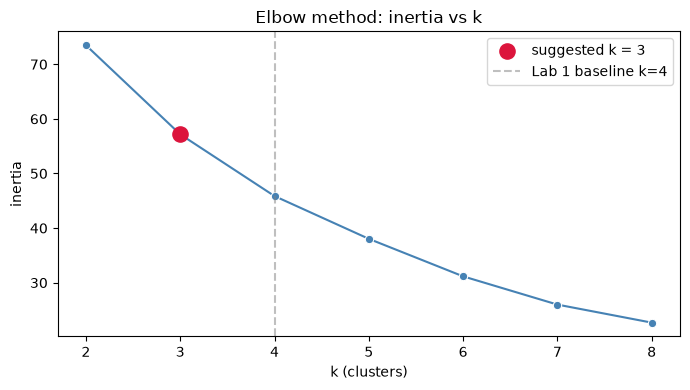

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=results_df, x="k", y="inertia", marker="o", ax=ax, color="steelblue")
ax.scatter([suggested_k], [results_df.loc[results_df["k"] == suggested_k, "inertia"].iloc[0]],
           color="crimson", s=120, zorder=5, label=f"suggested k = {suggested_k}")
ax.axvline(4, color="gray", linestyle="--", alpha=0.5, label="Lab 1 baseline k=4")
ax.set_xlabel("k (clusters)")
ax.set_ylabel("inertia")
ax.set_title("Elbow method: inertia vs k")
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout()
plt.show()


## Compare k=3 and k=4

In [8]:
inertia_k3 = next(v for k, v in inertias if k == 3)
inertia_k4 = next(v for k, v in inertias if k == 4)

compare = pd.DataFrame({
    "setting": ["Lab 2 elbow (k=3)", "Lab 1 baseline (k=4)"],
    "k": [3, 4],
    "inertia": [inertia_k3, inertia_k4],
})
display(compare.round(4))
print(f"inertia reduction 4→3: {inertia_k3 - inertia_k4:+.4f} (k=3 has higher inertia — fewer clusters)")


,setting,k,inertia
0,Lab 2 elbow (k=3),3,57.1748
1,Lab 1 baseline (k=4),4,45.8634


inertia reduction 4→3: +11.3115 (k=3 has higher inertia — fewer clusters)


### Elbow analysis prompt 1

Reformat inertia values as a dict for quick lookup.

In [9]:
inertia_by_k = dict(inertias)
print(inertia_by_k)

{2: 73.49320021830653, 3: 57.17484478176046, 4: 45.863362608359274, 5: 38.03228858010226, 6: 31.161291961672926, 7: 25.986982966291457, 8: 22.68502284994009}


### Elbow analysis prompt 2

Show relative drop percentage vs previous k.

In [10]:
tmp = results_df.copy(); tmp['pct_drop'] = tmp['inertia_drop'] / tmp['inertia'].shift(1); display(tmp.round(4))

,k,inertia,inertia_drop,suggested,pct_drop
0,2,73.4932,-16.3184,False,NaN
1,3,57.1748,-11.3115,True,-0.1539
2,4,45.8634,-7.8311,False,-0.1370
3,5,38.0323,-6.8710,False,-0.1498
4,6,31.1613,-5.1743,False,-0.1361
5,7,25.9870,-3.3020,False,-0.1060
6,8,22.6850,NaN,False,NaN


### Elbow analysis prompt 3

Identify the two biggest drops.

In [11]:
display(results_df.nlargest(2, 'inertia_drop')[['k','inertia_drop']])

,k,inertia_drop
5,7,-3.301960
4,6,-5.174309


### Elbow analysis prompt 4

List inertias rounded to 2 decimals.

In [12]:
print([round(v, 2) for _, v in inertias])

[73.49, 57.17, 45.86, 38.03, 31.16, 25.99, 22.69]


### Elbow analysis prompt 5

What happens if we choose k=5?

In [13]:
print('inertia@k5 =', round(dict(inertias)[5], 4))

inertia@k5 = 38.0323


### Elbow analysis prompt 6

Compute first derivative approximation.

In [14]:
results_df['delta_prev'] = results_df['inertia'].diff(); display(results_df.round(4))

,k,inertia,inertia_drop,suggested,delta_prev
0,2,73.4932,-16.3184,False,NaN
1,3,57.1748,-11.3115,True,-16.3184
2,4,45.8634,-7.8311,False,-11.3115
3,5,38.0323,-6.8710,False,-7.8311
4,6,31.1613,-5.1743,False,-6.8710
5,7,25.9870,-3.3020,False,-5.1743
6,8,22.6850,NaN,False,-3.3020


### Elbow analysis prompt 7

Mark all candidates with drop > 10.

In [15]:
display(results_df.loc[results_df['inertia_drop'] > 10, ['k', 'inertia_drop']])

,k,inertia_drop


### Elbow analysis prompt 8

Sort by inertia ascending.

In [16]:
display(results_df.sort_values('inertia').round(4))

,k,inertia,inertia_drop,suggested,delta_prev
6,8,22.6850,NaN,False,-3.3020
5,7,25.9870,-3.3020,False,-5.1743
4,6,31.1613,-5.1743,False,-6.8710
3,5,38.0323,-6.8710,False,-7.8311
2,4,45.8634,-7.8311,False,-11.3115
1,3,57.1748,-11.3115,True,-16.3184
0,2,73.4932,-16.3184,False,NaN


### Elbow analysis prompt 9

Plot drops as bars.

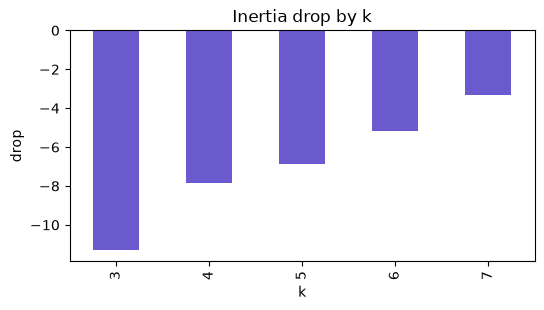

In [17]:
ax = results_df.dropna().plot(x='k', y='inertia_drop', kind='bar', figsize=(6,3), legend=False, color='slateblue'); ax.set_ylabel('drop'); ax.set_title('Inertia drop by k');

### Elbow analysis prompt 10

Review selected recommendation.

In [18]:
print({'suggested_k': suggested_k, 'reason': 'largest immediate drop'})

{'suggested_k': 3, 'reason': 'largest immediate drop'}


### Elbow analysis prompt 11

Display k and inertia as markdown-like rows.

In [19]:
for _, r in results_df.iterrows():
    print(f"k={int(r['k'])}: inertia={r['inertia']:.4f}")

k=2: inertia=73.4932
k=3: inertia=57.1748
k=4: inertia=45.8634
k=5: inertia=38.0323
k=6: inertia=31.1613
k=7: inertia=25.9870
k=8: inertia=22.6850


### Elbow analysis prompt 12

Check monotonic inertia behavior.

In [20]:
vals = results_df['inertia'].tolist(); print(all(vals[i] > vals[i+1] for i in range(len(vals)-1)))

True


### Elbow analysis prompt 13

Estimate elbow with second differences.

In [21]:
vals = [v for _, v in inertias]; second = [vals[i-1]-2*vals[i]+vals[i+1] for i in range(1, len(vals)-1)]; print(second)

[5.006873263144875, 3.4804081451441746, 0.9600774098276794, 1.6966876230478647, 1.8723488790301026]


### Elbow analysis prompt 14

Compare average inertia for low vs high k.

In [22]:
print({'k2-4': round(results_df.loc[results_df['k'].between(2,4), 'inertia'].mean(),4), 'k5-8': round(results_df.loc[results_df['k'].between(5,8), 'inertia'].mean(),4)})

{'k2-4': np.float64(58.8438), 'k5-8': np.float64(29.4664)}


### Elbow analysis prompt 15

Display one-sentence decision aid.

In [23]:
print('Pick k=3 for simpler segmentation, k=4 for tighter compactness.')

Pick k=3 for simpler segmentation, k=4 for tighter compactness.


### Elbow analysis prompt 16

Compute marginal benefit k=7->8.

In [24]:
vals = dict(inertias); print(round(vals[7]-vals[8], 4))

3.302

### Elbow analysis prompt 17

Check inertia ratio k3/k4.

In [25]:
vals = dict(inertias); print(round(vals[3]/vals[4], 4))

1.2466


### Elbow analysis prompt 18

Render compact summary table.

In [26]:
display(results_df[['k','inertia','suggested']].round(4))

,k,inertia,suggested
0,2,73.4932,False
1,3,57.1748,True
2,4,45.8634,False
3,5,38.0323,False
4,6,31.1613,False
5,7,25.9870,False
6,8,22.6850,False


### Elbow analysis prompt 19

Reconfirm symbols count.

In [27]:
print('symbols:', len(features), '| columns:', features.shape[1])

symbols: 25 | columns: 5


### Elbow analysis prompt 20

Bridge to next lab.

In [28]:
print('Lab 3 switches to density-based clustering and noise detection.')

Lab 3 switches to density-based clustering and noise detection.


### Lab 2 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [29]:
print("Lab 2 recap step 1: completed")

Lab 2 recap step 1: completed


### Lab 2 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [30]:
print("Lab 2 recap step 2: completed")

Lab 2 recap step 2: completed


### Lab 2 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [31]:
print("Lab 2 recap step 3: completed")

Lab 2 recap step 3: completed

### Lab 2 quick recap 4

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 2 recap step 4: completed")

Lab 2 recap step 4: completed


### Lab 2 quick recap 5

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 2 recap step 5: completed")

Lab 2 recap step 5: completed


## Final checkpoint

In [34]:
assert len(inertias) == 7
assert suggested_k == 3
inertia_by_k = dict(inertias)
assert abs(inertia_by_k[4] - 45.8634) < 0.1
assert abs(inertia_by_k[3] - 57.1748) < 0.1
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

Why can elbow-based `k` differ from business-friendly segment count choices?